# M2: EEG grid with behavioral clicks overlaid

`PLANssvepvsBeh.md` M2: `plotting.plot_grid_with_clicks` (new) draws the EEG response as a heatmap with the actual (red, green) click points scattered on top, in one combined view -- complementing `01_explore.ipynb`'s side-by-side density comparison (`plot_overlap`). Shown for individual participants (their own mean grid + their own clicks), then repeated with behavioral outliers filtered out (`beh/scripts/features.py`'s `subject_outliers`/`group_outliers`, M4), then for groups/subgroups.

x/y limits capped to `[0, 3200]`/`[0, 2000]` (the EEG grid's own sampled range) throughout -- a handful of subjects' clicks run past green=2000, clipped at the axis edge rather than expanding the view, so every plot stays visually comparable.

In [1]:
import sys
sys.path.append('../../beh/scripts')
sys.path.append('../scripts')

import loader as beh_loader
import features as beh_features
import overlap

sys.path.insert(0, '../scripts')
import plotting

analysis = overlap.analysis
beh_df = beh_loader.load_behavioral()
runmap_df = analysis.load_runmap()
baselines_df = analysis.load_baselines()
metadata_df = analysis.load_metadata()
SESSION = 1

## Which subjects run past green=2000?

In [2]:
over = beh_df[beh_df['green'] > 2000][['sub_id', 'green']].groupby('sub_id')['green'].agg(['count', 'max'])
over.rename(columns={'count': 'n_clicks_over_2000', 'max': 'max_green'})

,n_clicks_over_2000,max_green
sub_id,,
MET030,4,2313.0
MET032,4,2319.0
MET033,2,2172.0
MET034,7,2237.0
MET040,7,2380.0
MET041,1,2153.0
MET043,4,2184.0


## Individual participants

One example per group/subtype -- the function works the same way for any `sub_id`, change `example_subjects` to look at others.

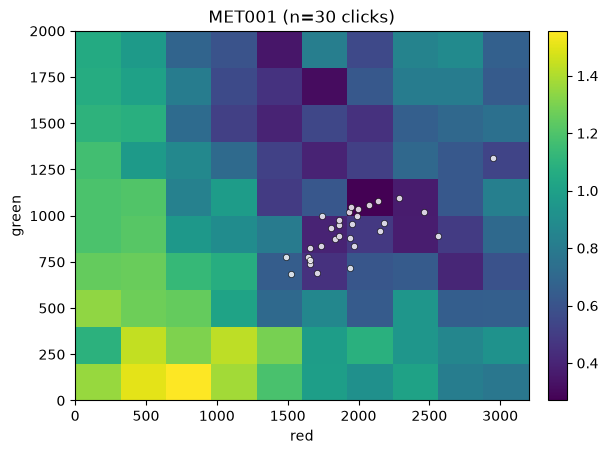

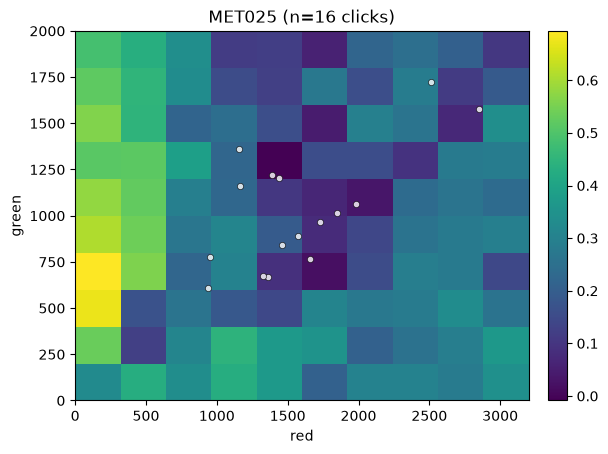

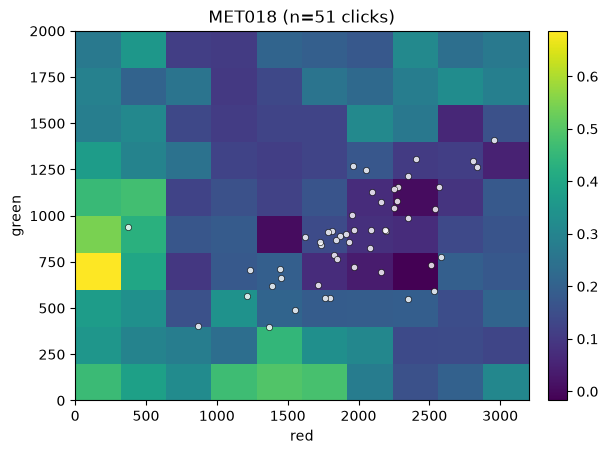

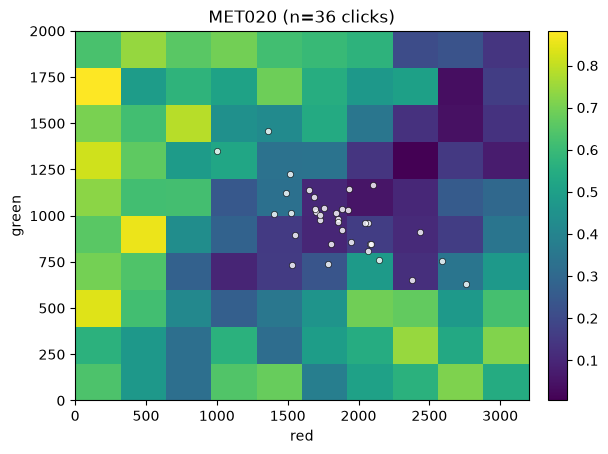

In [3]:
example_subjects = ['MET001', 'MET025', 'MET018', 'MET020']  # HC, PD, protan, deutan
for sub_id in example_subjects:
    E = analysis.mean_grid(runmap_df, baselines_df, sub_id, SESSION, normalize=analysis.DEFAULT_NORMALIZE)
    clicks = beh_df[beh_df['sub_id'] == sub_id]
    plotting.plot_grid_with_clicks(E, clicks, title=f'{sub_id} (n={len(clicks)} clicks)')

### Repeated with behavioral outliers removed (n_std=2.0, each subject's own ellipse)

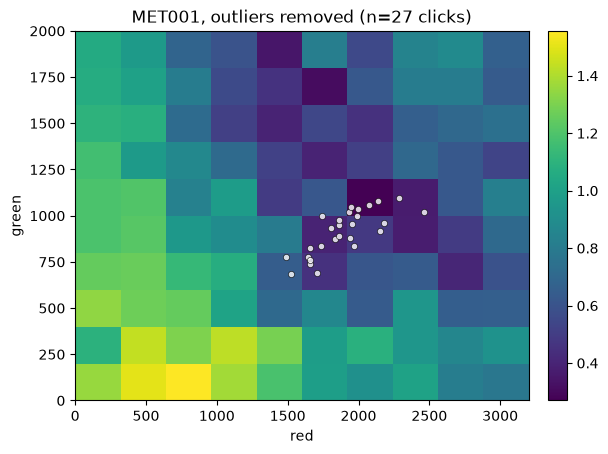

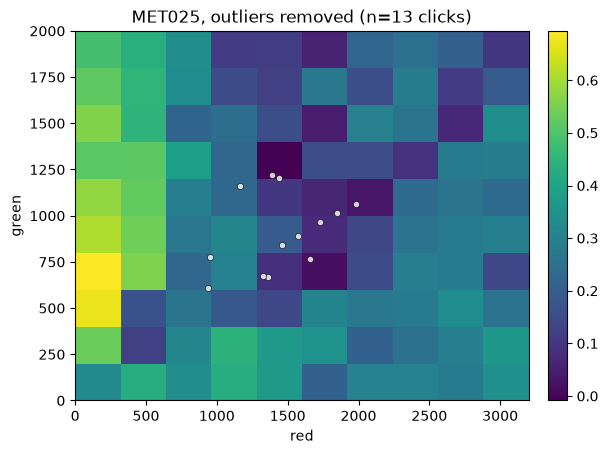

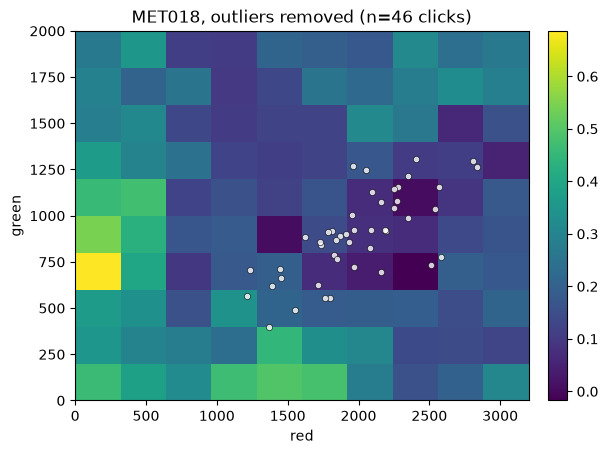

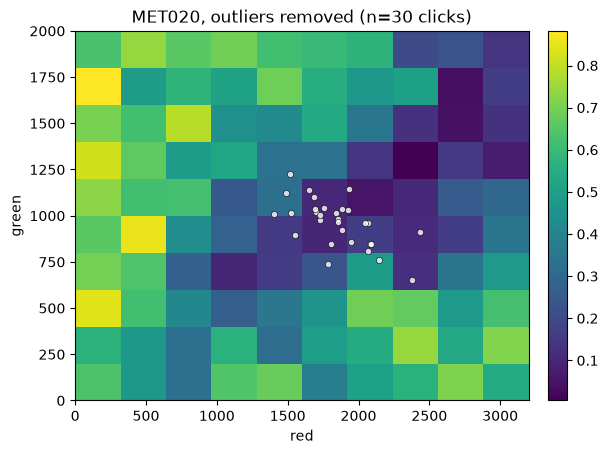

In [4]:
for sub_id in example_subjects:
    E = analysis.mean_grid(runmap_df, baselines_df, sub_id, SESSION, normalize=analysis.DEFAULT_NORMALIZE)
    result = beh_features.subject_outliers(beh_df, sub_id, n_std=2.0)
    inliers = beh_df[beh_df['sub_id'] == sub_id][~result['outlier_mask']]
    plotting.plot_grid_with_clicks(E, inliers, title=f'{sub_id}, outliers removed (n={len(inliers)} clicks)')

## Groups/subgroups

Mean group EEG grid vs. every group member's clicks pooled.

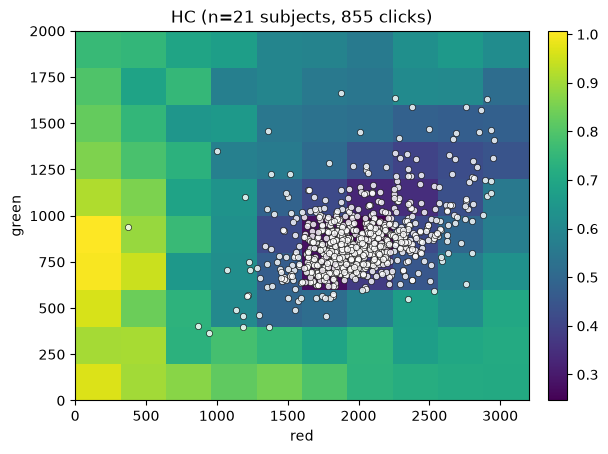

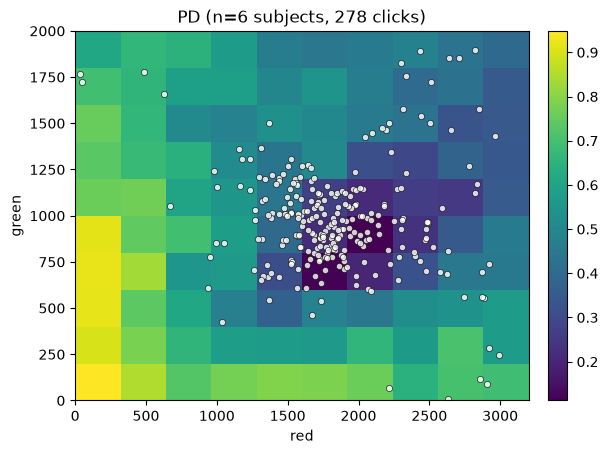

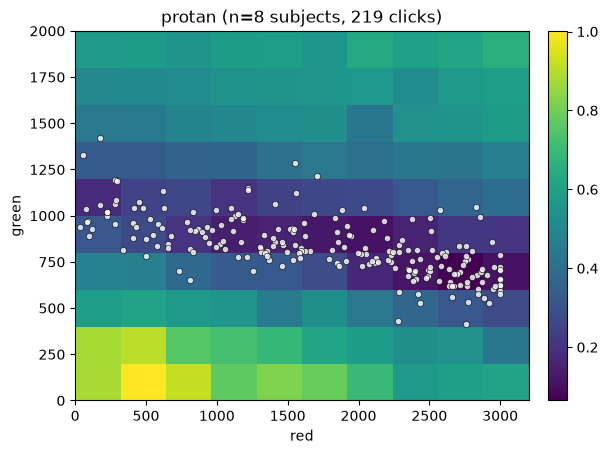

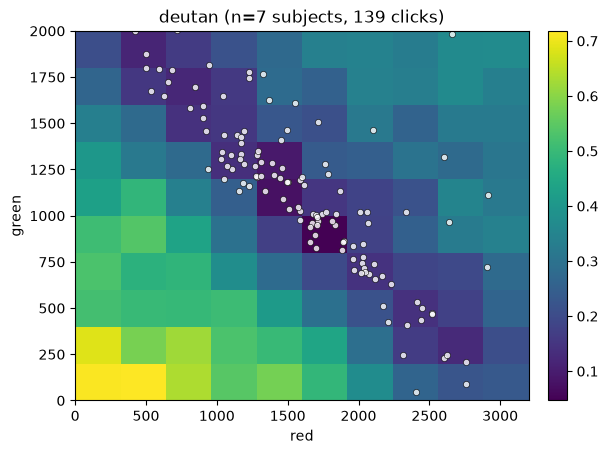

In [5]:
group_categories = [
    {'label': 'HC', 'group': 'CTR'},
    {'label': 'PD', 'group': 'PD'},
    {'label': 'protan', 'subgroup': 'protan'},
    {'label': 'deutan', 'subgroup': 'deutan'},
]
for cat in group_categories:
    sub_ids = analysis.subjects_in_group(metadata_df, SESSION, group=cat.get('group'), subgroup=cat.get('subgroup'))
    E = analysis.mean_grid_across_subjects(runmap_df, baselines_df, sub_ids, SESSION, normalize=analysis.DEFAULT_NORMALIZE)
    clicks = beh_df[beh_df['sub_id'].isin(sub_ids)]
    plotting.plot_grid_with_clicks(E, clicks, title=f"{cat['label']} (n={len(sub_ids)} subjects, {len(clicks)} clicks)")

### Repeated with behavioral outliers removed (n_std=2.0, one shared ellipse per group)

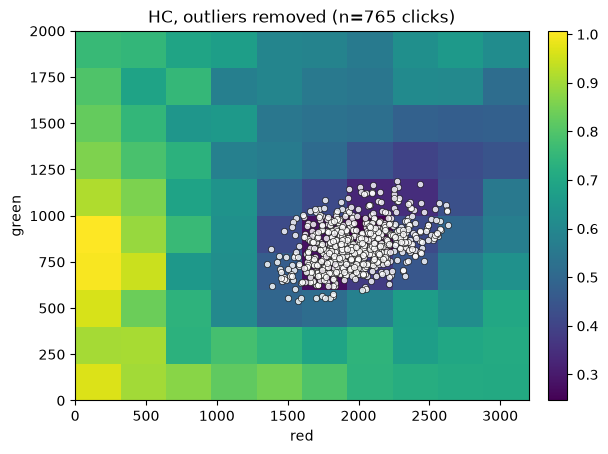

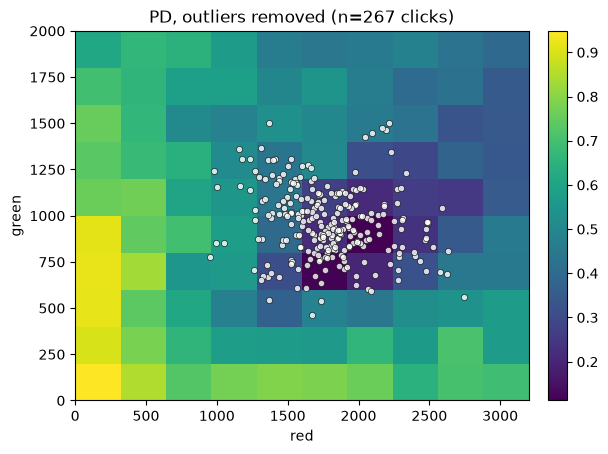

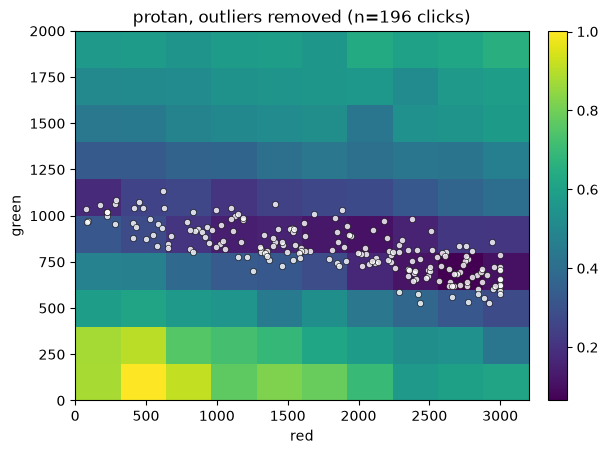

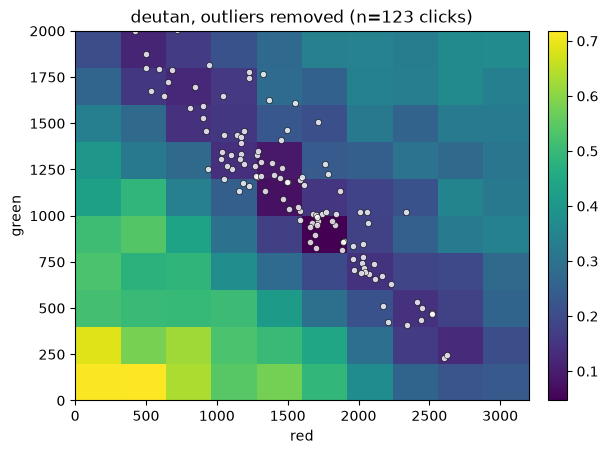

In [6]:
for cat in group_categories:
    sub_ids = analysis.subjects_in_group(metadata_df, SESSION, group=cat.get('group'), subgroup=cat.get('subgroup'))
    E = analysis.mean_grid_across_subjects(runmap_df, baselines_df, sub_ids, SESSION, normalize=analysis.DEFAULT_NORMALIZE)
    result = beh_features.group_outliers(beh_df, group=cat.get('group'), subgroup=cat.get('subgroup'), n_std=2.0)
    inlier_ids = result['table'].loc[~result['table']['is_outlier'], ['sub_id', 'red', 'green']]
    plotting.plot_grid_with_clicks(E, inlier_ids, title=f"{cat['label']}, outliers removed (n={len(inlier_ids)} clicks)")

## Summary

**Subjects whose clicks run past green=2000** (the EEG grid's own sampled range): MET030, MET032, MET033, MET034, MET040, MET041, MET043 -- 7 subjects, 1-7 such clicks each, max green up to 2380 (MET040). Shown clipped at the axis edge throughout, not expanding the view.

The combined view makes the same story `01_explore.ipynb`'s side-by-side density comparison already established visually direct: clicks sit in the EEG grid's darkest (lowest-response) region for every example subject and group shown, individual outlier points included (e.g. MET001 has one click far from its own main cluster, clearly visible once outliers are marked). Removing outliers tightens the visual cluster without changing the qualitative picture -- consistent with `beh/`'s M4 finding that nothing about the flagged outlier fractions looked systematically alarming for any group.